In [1]:
#! Imports, source-only preflight, existing checkpoints and paths
import hashlib
import importlib.util
import json
import random
import sys
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount('/content/drive')

SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

PACS_DIR = ROOT / 'data/pacs'
SHARED_DIR = ROOT / 'shared'
SPLIT_PATH = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
TASK2 = ROOT / 'task2'
TASK3 = ROOT / 'task3'
METHOD_DIR = TASK3 / 'methods'
MODEL_DIR = TASK3 / 'models'
CONFIG_DIR = TASK3 / 'configs'
RESULT_DIR = TASK3 / 'results/sam'
BASE_PATH = TASK2 / 'configs/base.json'
ERM_RUN_PATH = TASK2 / 'configs/source_only.json'
INITIAL_PATH = TASK2 / 'models/resnet18_initial_seed6304.pt'
ERM_BEST_PATH = TASK2 / 'models/source_only_best.pt'
ERM_LAST_PATH = TASK2 / 'models/source_only_last.pt'
METHOD_FILE = METHOD_DIR / 'sam_task3.py'
RUN_CONFIG_PATH = CONFIG_DIR / 'sam.json'
BEST_PATH = MODEL_DIR / 'sam_best.pt'
LAST_PATH = MODEL_DIR / 'sam_last.pt'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']

def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

required = [PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'source_train.csv',
            PACS_DIR / 'source_val.csv', SHARED_DIR / 'pacs.py',
            SHARED_DIR / 'pacs_training.py', SPLIT_PATH, BASE_PATH,
            ERM_RUN_PATH, INITIAL_PATH, ERM_BEST_PATH, ERM_LAST_PATH]

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Complete Task 2A/2B first; missing: ' + str(missing))

base = json.loads(BASE_PATH.read_text())
erm_run = json.loads(ERM_RUN_PATH.read_text())
split = json.loads(SPLIT_PATH.read_text())

if (base['seed'] != SEED or split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS
        or erm_run['base_config_sha256'] != sha256(BASE_PATH)
        or erm_run['source_split_sha256'] != sha256(SPLIT_PATH)
        or erm_run['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)):
    raise RuntimeError('Locked source protocol differs from Task 2B; inspect before proceeding')

erm_last = torch.load(ERM_LAST_PATH, map_location='cpu', weights_only=True)
erm_best = torch.load(ERM_BEST_PATH, map_location='cpu', weights_only=True)

if (not erm_last['finished'] or erm_best['method'] != 'source_only_erm'
        or erm_best['run_config_sha256'] != sha256(ERM_RUN_PATH)
        or erm_best['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or erm_best['epoch'] != erm_last['best_epoch']):
    raise RuntimeError('Task 2B ERM must be complete and its provenance must match')

LABEL_NAMES = base['class_names']

if len(LABEL_NAMES) != 7:
    raise RuntimeError('Expected seven PACS classes')

for folder in (METHOD_DIR, MODEL_DIR, CONFIG_DIR, RESULT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE, '| T4 GPU recommended')
print('Task 2B ERM checkpoint:', ERM_BEST_PATH, '| best epoch:', erm_best['epoch'])
print('SAM outputs (only):', MODEL_DIR, RESULT_DIR)
print('Target archive / manifest not accessed.')

Mounted at /content/drive
Device: cuda | T4 GPU recommended
Task 2B ERM checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/source_only_best.pt | best epoch: 9
SAM outputs (only): /content/drive/MyDrive/pa1-beyond-iid/task3/models /content/drive/MyDrive/pa1-beyond-iid/task3/results/sam
Target archive / manifest not accessed.


In [2]:
#! Load exactly the same source splits, transforms and sampling as Task 2B
sys.path.insert(0, str(SHARED_DIR))

from pacs import make_loaders, set_seed, freeze_bn_running_stats
from pacs_training import (set_epoch_loaders, evaluate_sources,
                           atomic_torch_save, cpu_state_dict)

LOCAL_ROOT = Path('/content/pacs_task3b_sources_only')

if (LOCAL_ROOT / 'images/sketch').exists():
    raise RuntimeError('Fresh source-only runtime required; unexpected Sketch folder exists')

source_loaders, val_loaders = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=False, workers=2
)

train_manifest = pd.read_csv(PACS_DIR / 'source_train.csv')
val_manifest = pd.read_csv(PACS_DIR / 'source_val.csv')

if set(train_manifest['hf_index']) & set(val_manifest['hf_index']):
    raise RuntimeError('Overlapping source train and validation images')

for domain in SOURCE_DOMAINS:
    expected_train = set(split['source_splits'][domain]['train_indices'])
    expected_val = set(split['source_splits'][domain]['val_indices'])
    train_ids = set(train_manifest.loc[train_manifest.domain == domain, 'hf_index'])
    val_ids = set(val_manifest.loc[val_manifest.domain == domain, 'hf_index'])

    if (train_ids != expected_train or val_ids != expected_val):
        raise RuntimeError('Frozen source split changed: ' + domain)

    if source_loaders[domain].batch_size != 8 or not source_loaders[domain].drop_last:
        raise RuntimeError('SAM requires full 8-image batches from each source: ' + domain)

    if len(source_loaders[domain]) == 0 or len(val_loaders[domain]) == 0:
        raise RuntimeError('Empty source train/validation loader: ' + domain)

    print(f'{domain}: {len(source_loaders[domain].dataset)} train; '
          f'{len(val_loaders[domain].dataset)} validation')

STEPS = max(len(loader) for loader in source_loaders.values())

if STEPS != erm_run['steps_per_source_epoch']:
    raise RuntimeError('SAM epoch length does not match Task 2B')

print('Updates per epoch:', STEPS, '| 8 + 8 + 8 = 24 labeled source images/update')
print('No Sketch loader constructed.')

photo: 1336 train; 334 validation
art_painting: 1638 train; 410 validation
cartoon: 1875 train; 469 validation
Updates per epoch: 234 | 8 + 8 + 8 = 24 labeled source images/update
No Sketch loader constructed.


In [3]:
#! Save isolated SAM code; prove two-pass update against a manual reference
METHOD_SOURCE = r'''
#! Standard, non-adaptive SAM: two source-CE passes, one optimizer update
import torch
import torch.nn.functional as F


def sam_step(model, optimizer, images, labels, rho=0.05):
    #! The SAME prepared minibatch is used in both passes; BN modes are set by caller.

    if rho <= 0:
        raise ValueError('SAM radius must be positive')

    optimizer.zero_grad(set_to_none=True)
    clean_logits = model(images)
    clean_loss = F.cross_entropy(clean_logits, labels)

    if not bool(torch.isfinite(clean_loss).item()):
        raise FloatingPointError('Non-finite SAM first-pass source CE')

    predictions = clean_logits.detach().argmax(dim=1)
    clean_loss.backward()

    #! Global L2 norm over every trainable parameter; inf is a finite-check, NOT clipping.
    gradient_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), max_norm=float('inf'), error_if_nonfinite=True
    )

    if gradient_norm.item() <= 0:
        raise FloatingPointError('Zero SAM gradient: normalized ascent is undefined')

    scale = float(rho) / gradient_norm
    offsets = []
    try:
        with torch.no_grad():
            for parameter in model.parameters():
                if parameter.grad is not None:
                    epsilon = parameter.grad.detach().clone().mul_(scale)
                    parameter.add_(epsilon)
                    offsets.append((parameter, epsilon))

        #! Clear first-pass gradients; differentiate ONLY the perturbed loss.
        optimizer.zero_grad(set_to_none=True)
        perturbed_loss = F.cross_entropy(model(images), labels)

        if not bool(torch.isfinite(perturbed_loss).item()):
            raise FloatingPointError('Non-finite SAM second-pass source CE')

        perturbed_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=float('inf'), error_if_nonfinite=True
        )
    finally:
        #! Restore unperturbed parameters EVEN IF the second pass fails.
        with torch.no_grad():
            for parameter, epsilon in offsets:
                parameter.sub_(epsilon)

    #! AdamW applies exactly ONCE at original theta, with gradient at theta + epsilon.
    optimizer.step()
    return {
        'clean_ce': clean_loss.detach().item(),
        'perturbed_ce': perturbed_loss.detach().item(),
        'first_gradient_norm': gradient_norm.detach().item(),
        'perturbation_l2': torch.linalg.vector_norm(torch.stack([
            torch.linalg.vector_norm(epsilon) for _, epsilon in offsets
        ])).detach().item(),
        'predictions': predictions,
    }
'''

if METHOD_FILE.is_file():
    if METHOD_FILE.read_text() != METHOD_SOURCE:
        raise RuntimeError('Existing Task 3 SAM method differs; preserve it and inspect before overwriting')
else:
    METHOD_FILE.write_text(METHOD_SOURCE)

spec = importlib.util.spec_from_file_location('atml_pa1_task3_sam', METHOD_FILE)
sam_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sam_module)
sam_step = sam_module.sam_step

#! Tiny two-pass reference: compare SAM parameters to manually calculated second gradient.
import copy
import torch.nn.functional as F

set_seed(SEED)

toy = nn.Sequential(nn.BatchNorm1d(4), nn.Linear(4, 7))
toy[0].eval()

manual = copy.deepcopy(toy)
manual[0].eval()

inputs = torch.randn(24, 4)
targets = torch.arange(24) % 7

rho, toy_lr = 0.05, 1e-2
opt_toy = torch.optim.SGD(toy.parameters(), lr=toy_lr)
opt_manual = torch.optim.SGD(manual.parameters(), lr=toy_lr)
bn_before = toy[0].running_mean.detach().clone()

opt_manual.zero_grad(set_to_none=True)
manual_clean = F.cross_entropy(manual(inputs), targets)
manual_clean.backward()
manual_norm = torch.nn.utils.clip_grad_norm_(manual.parameters(), float('inf'))

perturbations = []

with torch.no_grad():
    for param in manual.parameters():
        if param.grad is not None:
            eps = param.grad.detach().clone() * (rho / manual_norm)
            param.add_(eps)
            perturbations.append((param, eps))

opt_manual.zero_grad(set_to_none=True)
manual_perturbed = F.cross_entropy(manual(inputs), targets)
manual_perturbed.backward()

with torch.no_grad():
    for param, eps in perturbations:
        param.sub_(eps)
opt_manual.step()

measured = sam_step(toy, opt_toy, inputs, targets, rho=rho)

for actual, expected in zip(toy.parameters(), manual.parameters()):
    if not torch.allclose(actual, expected, atol=1e-6, rtol=1e-6):
        raise RuntimeError('SAM two-pass update does not match manual reference')

if (abs(measured['perturbation_l2'] - rho) > 1e-6
        or abs(measured['perturbed_ce'] - manual_perturbed.detach().item()) > 1e-6
        or not torch.equal(toy[0].running_mean, bn_before)
        or toy[0].weight.grad is None or toy[0].bias.grad is None):
    raise RuntimeError('SAM perturbation norm, BN freeze or affine gradient check failed')

del toy, manual, inputs, targets, opt_toy, opt_manual

set_seed(SEED)
print('SAM reference update, rho norm, two-pass BN and affine gradients: PASS')
print('Task 3-only SAM module:', METHOD_FILE)

SAM reference update, rho norm, two-pass BN and affine gradients: PASS
Task 3-only SAM module: /content/drive/MyDrive/pa1-beyond-iid/task3/methods/sam_task3.py


In [4]:
#! Lock the SAM design, initialize exactly from shared weights and resume complete epochs
INITIAL_SHA = sha256(INITIAL_PATH)
initial = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)

if initial['seed'] != SEED or initial['class_names'] != LABEL_NAMES:
    raise RuntimeError('SAM initialization seed/classes do not match the shared checkpoint')

BN_REFERENCE = {name: value.detach().cpu().clone()
                for name, value in initial['model_state_dict'].items()
                if name.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

RHO = 0.05

RUN_CONFIG = {
    'method': 'sam', 'seed': SEED, 'rho': RHO,
    'sam_variant': 'standard (non-adaptive), global L2 gradient perturbation',
    'source_only_config_sha256': sha256(ERM_RUN_PATH),
    'erm_baseline_checkpoint_sha256': sha256(ERM_BEST_PATH),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'base_config_sha256': sha256(BASE_PATH),
    'source_split_sha256': sha256(SPLIT_PATH),
    'train_manifest_sha256': sha256(PACS_DIR / 'source_train.csv'),
    'val_manifest_sha256': sha256(PACS_DIR / 'source_val.csv'),
    'pacs_module_sha256': sha256(SHARED_DIR / 'pacs.py'),
    'training_module_sha256': sha256(SHARED_DIR / 'pacs_training.py'),
    'sam_method_module_sha256': sha256(METHOD_FILE),
    'source_domains': SOURCE_DOMAINS,
    'batch_per_source': 8, 'steps_per_epoch': STEPS,
    'epoch_definition': 'longest source loader once; cycle shorter sources',
    'architecture': 'torchvision ImageNet ResNet-18, seven-class fully fine-tuned classifier',
    'pretrained_initialization': 'shared Task 2B initial, NOT trained ERM',
    'loss': 'mean source CE at theta+epsilon; epsilon=rho*g/||g||_2',
    'forward_backward_passes_per_update': 2, 'adamw_steps_per_update': 1,
    'optimizer': 'AdamW', 'learning_rate': base['learning_rate'],
    'weight_decay': base['weight_decay'],
    'max_epochs': base['max_source_epochs'],
    'patience': base['early_stopping_patience'],
    'checkpoint_metric': 'mean source validation macro-F1',
    'batchnorm': 'ImageNet running buffers frozen on BOTH passes; affine trainable',
    'precision': 'FP32, AMP disabled before starting',
    'target_images_loaded': False, 'target_labels_used': False,
    'target_results_used_for_selection': False,
    'sketch_evaluation': 'deferred to Task 3D after decisions are locked',
}

if (RUN_CONFIG['learning_rate'] != erm_run['learning_rate']
        or RUN_CONFIG['weight_decay'] != erm_run['weight_decay']
        or RUN_CONFIG['max_epochs'] != erm_run['max_epochs']
        or RUN_CONFIG['patience'] != erm_run['patience']):
    raise RuntimeError('SAM must use the exact ERM optimizer, budget and early stopping')

if RUN_CONFIG_PATH.is_file():
    if json.loads(RUN_CONFIG_PATH.read_text()) != RUN_CONFIG:
        raise RuntimeError('Existing SAM run configuration differs; do not overwrite checkpoints')
else:
    RUN_CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2))

RUN_SHA = sha256(RUN_CONFIG_PATH)

set_seed(SEED)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(initial['model_state_dict'], strict=True)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=RUN_CONFIG['learning_rate'],
                               weight_decay=RUN_CONFIG['weight_decay'])

history = []
best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1

training_finished = False

if LAST_PATH.is_file():
    last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)

    if last['run_config_sha256'] != RUN_SHA or last.get('method') != 'sam':
        raise RuntimeError('SAM resume checkpoint belongs to a different experiment')

    model.load_state_dict(last['model_state_dict'], strict=True)
    optimizer.load_state_dict(last['optimizer_state_dict'])
    random.setstate(last['python_rng_state'])
    torch.set_rng_state(last['torch_rng_state'])

    if DEVICE.type == 'cuda' and last.get('cuda_rng_state') is not None:
        torch.cuda.set_rng_state_all(last['cuda_rng_state'])

    history = last['history']
    best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']
    start_epoch, training_finished = last['epoch'] + 1, last['finished']

    if not BEST_PATH.is_file() or len(history) != last['epoch']:
        raise RuntimeError('Incomplete SAM checkpoint/history; do not overwrite saved results')

    print('Resuming AFTER complete epoch', last['epoch'], '| finished:', training_finished)
elif BEST_PATH.is_file():
    raise RuntimeError('SAM best checkpoint exists without resume checkpoint; inspect before proceeding')
else:
    print('New SAM run: same initial weights as ERM, NOT trained ERM.')

print('Locked config:', RUN_CONFIG_PATH)
print('Full FP32 training; two forward/backward passes, one AdamW step/update')

New SAM run: same initial weights as ERM, NOT trained ERM.
Locked config: /content/drive/MyDrive/pa1-beyond-iid/task3/configs/sam.json
Full FP32 training; two forward/backward passes, one AdamW step/update


In [5]:
#! Initial state audit: identical weights, frozen BN buffers and finite parameters
state = model.state_dict()

if any(not torch.equal(state[name].detach().cpu(), value)
       for name, value in BN_REFERENCE.items()) and not LAST_PATH.is_file():
    raise RuntimeError('Pretrained BatchNorm running buffers changed before SAM training')

if not all(layer.weight.requires_grad and layer.bias.requires_grad
           for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)):
    raise RuntimeError('BatchNorm affine parameters must stay trainable')

if any(not torch.isfinite(parameter).all().item() for parameter in model.parameters()):
    raise FloatingPointError('Non-finite SAM parameters before training')

model.eval()

with torch.inference_mode():
    probe = model(torch.randn(2, 3, 64, 64, device=DEVICE))

if probe.shape != (2, 7) or not torch.isfinite(probe).all().item():
    raise RuntimeError('ResNet 7-class forward smoke test failed')

del probe

print('ResNet forward, finite parameters, BN affine and initialization audit: PASS')
print('Completed epochs restored:', start_epoch - 1)

ResNet forward, finite parameters, BN affine and initialization audit: PASS
Completed epochs restored: 0


In [6]:
#! Source-only SAM: two FP32 passes on each batch, source-validation-only selection

def next_or_cycle(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        new_iterator = iter(loader)
        return next(new_iterator), new_iterator


def train_sam_epoch(epoch):
    model.train()

    freeze_bn_running_stats(model)
    set_epoch_loaders(source_loaders, epoch, SEED)

    iterators = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}

    sums = {'train_cls_loss': 0.0, 'train_perturbed_cls_loss': 0.0,
            'train_first_gradient_norm': 0.0, 'train_perturbation_norm': 0.0}

    total_correct = 0
    per_domain_correct = {domain: 0 for domain in SOURCE_DOMAINS}

    for step in range(STEPS):
        batches = []

        for domain in SOURCE_DOMAINS:
            batch, iterators[domain] = next_or_cycle(iterators[domain], source_loaders[domain])
            batches.append(batch)

        images = torch.cat([batch[0] for batch in batches], dim=0).to(DEVICE, non_blocking=True)
        labels = torch.cat([batch[1] for batch in batches], dim=0).to(DEVICE, non_blocking=True)

        if images.shape != (24, 3, 224, 224) or labels.shape != (24,):
            raise RuntimeError(f'Unexpected source batch: epoch={epoch}, step={step}')

        try:
            metrics = sam_step(model, optimizer, images, labels, rho=RHO)
        except (FloatingPointError, RuntimeError) as exc:
            raise RuntimeError(f'SAM failed at epoch={epoch}, step={step}; '
                               'restart from last COMPLETE epoch') from exc

        for field, key in [('train_cls_loss', 'clean_ce'),
                           ('train_perturbed_cls_loss', 'perturbed_ce'),
                           ('train_first_gradient_norm', 'first_gradient_norm'),
                           ('train_perturbation_norm', 'perturbation_l2')]:
            sums[field] += metrics[key]

        predictions = metrics['predictions']
        total_correct += int((predictions == labels).sum().item())

        for i, domain in enumerate(SOURCE_DOMAINS):
            per_domain_correct[domain] += int((predictions[i*8:(i+1)*8] ==
                                               labels[i*8:(i+1)*8]).sum().item())

    if any(not torch.isfinite(parameter).all().item() for parameter in model.parameters()):
        raise FloatingPointError(f'Non-finite SAM parameters after epoch {epoch}; no checkpoint saved')

    result = {key: value / STEPS for key, value in sums.items()}
    result.update({'train_total_loss': result['train_perturbed_cls_loss'],
                   'train_accuracy': total_correct / (24 * STEPS),
                   'updates': STEPS, 'forward_backward_passes': 2 * STEPS,
                   'source_examples_processed': 24 * STEPS,
                   'target_examples_processed': 0})
    result.update({f'train_{domain}_accuracy': per_domain_correct[domain] / (8 * STEPS)
                   for domain in SOURCE_DOMAINS})

    return result

if training_finished:
    print('SAM already completed; no training or checkpoint overwrite.')
else:
    for epoch in range(start_epoch, RUN_CONFIG['max_epochs'] + 1):
        tick = time.perf_counter()

        train_metrics = train_sam_epoch(epoch)
        source_val = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)
        score = source_val['mean_macro_f1']

        improved = score > best_f1 + 1e-8

        if improved:
            best_f1, best_epoch, bad_epochs = score, epoch, 0

            atomic_torch_save({
                'method': 'sam', 'seed': SEED, 'rho': RHO, 'epoch': epoch,
                'best_source_val_mean_macro_f1': best_f1,
                'source_validation': source_val,
                'run_config_sha256': RUN_SHA,
                'initial_checkpoint_sha256': INITIAL_SHA,
                'class_names': LABEL_NAMES,
                'model_state_dict': cpu_state_dict(model),
            }, BEST_PATH)

        else:
            bad_epochs += 1

        row = {
            'epoch': epoch, **train_metrics,
            'mean_source_val_accuracy': source_val['mean_accuracy'],
            'mean_source_val_macro_f1': source_val['mean_macro_f1'],
            'worst_source_val_accuracy': source_val['worst_source_accuracy'],
            'worst_source_val_macro_f1': source_val['worst_source_macro_f1'],
            'elapsed_seconds': time.perf_counter() - tick,
        }

        for domain in SOURCE_DOMAINS:
            row[f'val_{domain}_accuracy'] = source_val[domain]['accuracy']
            row[f'val_{domain}_macro_f1'] = source_val[domain]['macro_f1']
            row[f'val_{domain}_loss'] = source_val[domain]['loss']

        history.append(row)
        training_finished = bad_epochs >= RUN_CONFIG['patience'] or epoch == RUN_CONFIG['max_epochs']

        atomic_torch_save({
            'method': 'sam', 'epoch': epoch, 'finished': training_finished,
            'model_state_dict': cpu_state_dict(model),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1,
            'bad_epochs': bad_epochs, 'run_config_sha256': RUN_SHA,
            'python_rng_state': random.getstate(),
            'torch_rng_state': torch.get_rng_state(),
            'cuda_rng_state': torch.cuda.get_rng_state_all() if DEVICE.type == 'cuda' else None,
        }, LAST_PATH)

        pd.DataFrame(history).to_csv(RESULT_DIR / 'history.csv', index=False)
        print(f"Epoch {epoch:02d} | clean CE {row['train_cls_loss']:.4f} | "
              f"perturbed CE {row['train_perturbed_cls_loss']:.4f} | "
              f"radius {row['train_perturbation_norm']:.4f} | "
              f"source val F1 {score:.4f} | best {best_f1:.4f} "
              f"(epoch {best_epoch}) | patience {bad_epochs}/{RUN_CONFIG['patience']} | "
              f"{row['elapsed_seconds']:.1f}s")
        if training_finished:
            break

print('SAM finished:', training_finished, '| best epoch:', best_epoch,
      '| best mean source macro-F1:', round(best_f1, 5))

Epoch 01 | clean CE 0.7939 | perturbed CE 1.1013 | radius 0.0500 | source val F1 0.8922 | best 0.8922 (epoch 1) | patience 0/5 | 45.7s
Epoch 02 | clean CE 0.2439 | perturbed CE 0.4903 | radius 0.0500 | source val F1 0.9370 | best 0.9370 (epoch 2) | patience 0/5 | 47.6s
Epoch 03 | clean CE 0.1547 | perturbed CE 0.3659 | radius 0.0500 | source val F1 0.9425 | best 0.9425 (epoch 3) | patience 0/5 | 49.6s
Epoch 04 | clean CE 0.1161 | perturbed CE 0.3007 | radius 0.0500 | source val F1 0.9485 | best 0.9485 (epoch 4) | patience 0/5 | 52.0s
Epoch 05 | clean CE 0.0766 | perturbed CE 0.2321 | radius 0.0500 | source val F1 0.9404 | best 0.9485 (epoch 4) | patience 1/5 | 50.5s
Epoch 06 | clean CE 0.0611 | perturbed CE 0.2070 | radius 0.0500 | source val F1 0.9572 | best 0.9572 (epoch 6) | patience 0/5 | 51.8s
Epoch 07 | clean CE 0.0449 | perturbed CE 0.1697 | radius 0.0500 | source val F1 0.9520 | best 0.9572 (epoch 6) | patience 1/5 | 49.8s
Epoch 08 | clean CE 0.0337 | perturbed CE 0.1548 | radi

In [7]:
#! Best-checkpoint source-only evaluation and evidence for Task 3D

if not training_finished or not BEST_PATH.is_file():
    raise RuntimeError('Complete SAM training before source-only evaluation')

best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)

if (best['method'] != 'sam' or best['run_config_sha256'] != RUN_SHA
        or best['initial_checkpoint_sha256'] != INITIAL_SHA
        or best['epoch'] != best_epoch):
    raise RuntimeError('SAM checkpoint provenance or selection epoch mismatch')

model.load_state_dict(best['model_state_dict'], strict=True)
validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

if not np.isclose(validation['mean_macro_f1'], best['best_source_val_mean_macro_f1'], atol=1e-7):
    raise RuntimeError('SAM stored source macro-F1 differs from re-evaluation')

source_table = pd.DataFrame(
    [{'domain': domain, **validation[domain]} for domain in SOURCE_DOMAINS] +
    [{'domain': 'mean', 'accuracy': validation['mean_accuracy'],
      'macro_f1': validation['mean_macro_f1']},
     {'domain': 'worst', 'accuracy': validation['worst_source_accuracy'],
      'macro_f1': validation['worst_source_macro_f1']}]
)

source_table.to_csv(RESULT_DIR / 'source_validation.csv', index=False)
erm_csv = TASK2 / 'results/source_only/source_validation.csv'

if erm_csv.is_file():
    erm_table = pd.read_csv(erm_csv)
    comparison = erm_table[['domain', 'accuracy', 'macro_f1']].merge(
        source_table[['domain', 'accuracy', 'macro_f1']], on='domain',
        suffixes=('_erm', '_sam'), validate='one_to_one'
    )

    comparison.to_csv(RESULT_DIR / 'erm_vs_sam_source.csv', index=False)

    print('ERM vs SAM — source-validation only:')

    display(comparison.round(4))

summary = {
    'method': 'sam', 'seed': SEED, 'rho': RHO,
    'best_epoch': best['epoch'], 'source_validation': validation,
    'best_source_macro_f1': best['best_source_val_mean_macro_f1'],
    'checkpoint_path': str(BEST_PATH),
    'erm_checkpoint_sha256': sha256(ERM_BEST_PATH),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'target_images_loaded': False, 'target_labels_used': False,
    'target_evaluation': 'DEFERRED_TO_TASK3D',
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))

print('SAM source validation:')

display(source_table.round(4))

ERM vs SAM — source-validation only:


,domain,accuracy_erm,macro_f1_erm,accuracy_sam,macro_f1_sam
0,photo,0.9760,0.9726,0.9820,0.9795
1,art_painting,0.9122,0.9136,0.9317,0.9334
2,cartoon,0.9488,0.9524,0.9552,0.9587
3,mean,0.9457,0.9462,0.9563,0.9572
4,worst,0.9122,0.9136,0.9317,0.9334


SAM source validation:


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.9820,0.9795,0.0633,334.0
1,art_painting,0.9317,0.9334,0.2350,410.0
2,cartoon,0.9552,0.9587,0.1291,469.0
3,mean,0.9563,0.9572,NaN,NaN
4,worst,0.9317,0.9334,NaN,NaN


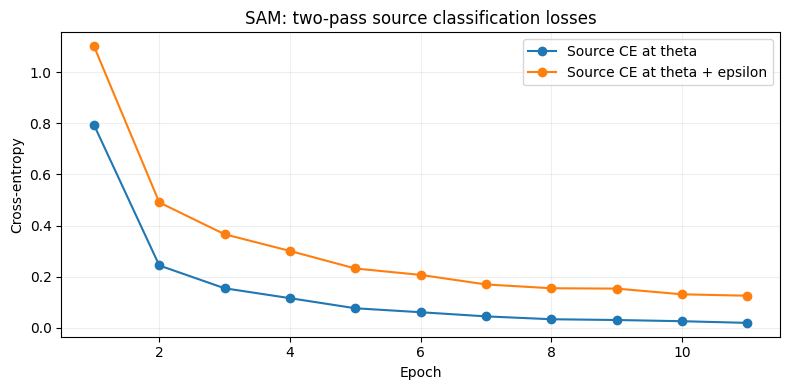

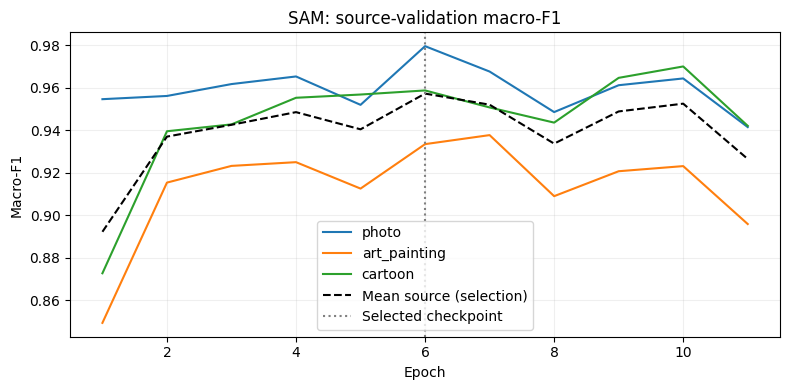

BatchNorm audit passed for 60 running-statistic buffers


In [8]:
#! Reusable SAM loss/F1 figures and strict frozen BatchNorm audit
history_df = pd.read_csv(RESULT_DIR / 'history.csv')

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(history_df['epoch'], history_df['train_cls_loss'], marker='o', label='Source CE at theta')
ax.plot(history_df['epoch'], history_df['train_perturbed_cls_loss'], marker='o',
        label='Source CE at theta + epsilon')
ax.set(xlabel='Epoch', ylabel='Cross-entropy', title='SAM: two-pass source classification losses')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'sam_training_losses.png', dpi=220)

plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for domain in SOURCE_DOMAINS:
    ax.plot(history_df['epoch'], history_df[f'val_{domain}_macro_f1'], label=domain)

ax.plot(history_df['epoch'], history_df['mean_source_val_macro_f1'],
        color='black', linestyle='--', label='Mean source (selection)')

ax.axvline(best_epoch, color='gray', linestyle=':', label='Selected checkpoint')
ax.set(xlabel='Epoch', ylabel='Macro-F1', title='SAM: source-validation macro-F1')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'sam_source_f1.png', dpi=220)

plt.show()

state = model.state_dict()
changed = [name for name, value in BN_REFERENCE.items()
           if not torch.equal(state[name].detach().cpu(), value)]

if changed:
    raise RuntimeError('SAM modified frozen pretrained BN buffers: ' + str(changed[:5]))
if not all(layer.weight.requires_grad and layer.bias.requires_grad
           for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)):
    raise RuntimeError('SAM froze BatchNorm scale/bias parameters')

(RESULT_DIR / 'batchnorm_audit.json').write_text(json.dumps({
    'running_buffers_equal_to_initial': True,
    'checked_buffer_count': len(BN_REFERENCE),
    'bn_affine_trainable': True,
    'both_sam_passes_used_bn_eval': True,
}, indent=2))

print('BatchNorm audit passed for', len(BN_REFERENCE), 'running-statistic buffers')

In [9]:
#! Final source-only integrity check: SAM checkpoints, F1, source IDs and BN audit
required = [METHOD_FILE, RUN_CONFIG_PATH, BEST_PATH, LAST_PATH,
            RESULT_DIR / 'history.csv', RESULT_DIR / 'source_validation.csv',
            RESULT_DIR / 'summary.json', RESULT_DIR / 'batchnorm_audit.json',
            RESULT_DIR / 'sam_training_losses.png', RESULT_DIR / 'sam_source_f1.png']

if (TASK2 / 'results/source_only/source_validation.csv').is_file():
    required.append(RESULT_DIR / 'erm_vs_sam_source.csv')

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Incomplete Task 3B outputs: ' + str(missing))

saved_best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
saved_last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)
saved_history = pd.read_csv(RESULT_DIR / 'history.csv')
saved_val = pd.read_csv(RESULT_DIR / 'source_validation.csv')

if (not saved_last['finished'] or len(saved_history) != saved_last['epoch']
        or saved_last['best_epoch'] != saved_best['epoch']
        or saved_best['run_config_sha256'] != sha256(RUN_CONFIG_PATH)
        or saved_best['initial_checkpoint_sha256'] != sha256(INITIAL_PATH)
        or not np.isclose(saved_best['best_source_val_mean_macro_f1'],
                          saved_val.loc[saved_val.domain == 'mean', 'macro_f1'].iloc[0], atol=1e-7)):
    raise RuntimeError('SAM checkpoint, history or source validation is inconsistent')

locked = json.loads(RUN_CONFIG_PATH.read_text())

if any([
    sha256(ERM_BEST_PATH) != locked['erm_baseline_checkpoint_sha256'],
    sha256(INITIAL_PATH) != locked['initial_checkpoint_sha256'],
    sha256(SPLIT_PATH) != locked['source_split_sha256'],
    sha256(METHOD_FILE) != locked['sam_method_module_sha256'],
    sha256(SHARED_DIR / 'pacs.py') != locked['pacs_module_sha256'],
    sha256(SHARED_DIR / 'pacs_training.py') != locked['training_module_sha256'],
]):
    raise RuntimeError('A locked upstream source dependency changed; inspect before continuing')

print('TASK 3B COMPLETE — SAM')
print('Verified files:', len(required))
print('Selected epoch:', saved_best['epoch'], '| source-validation macro-F1:',
      round(saved_best['best_source_val_mean_macro_f1'], 5))

print('Best SAM checkpoint:', BEST_PATH)
print('Sketch images or labels accessed: NO')

TASK 3B COMPLETE — SAM
Verified files: 11
Selected epoch: 6 | source-validation macro-F1: 0.95721
Best SAM checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task3/models/sam_best.pt
Sketch images or labels accessed: NO
